In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [3]:
subgraph_llm = ChatOpenAI(model='gpt-4o')

In [4]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}


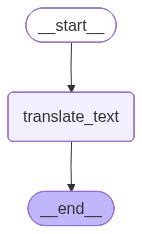

In [5]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()
subgraph

In [6]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [7]:
parent_llm = ChatOpenAI(model='gpt-4o-mini')

In [10]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}
    
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

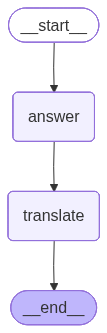

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)
graph = parent_builder.compile()

graph



In [12]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of matter and energy at very small scales, typically at the level of atoms and subatomic particles. It describes how these particles behave in ways that are often counterintuitive compared to classical physics.\n\nKey concepts in quantum physics include:\n\n1. **Wave-Particle Duality**: Particles such as electrons exhibit both wave-like and particle-like properties. This means they can behave like waves in certain experiments and like particles in others.\n\n2. **Uncertainty Principle**: Formulated by Werner Heisenberg, this principle states that certain pairs of physical properties, like position and momentum, cannot be simultaneously measured with arbitrary precision. The more accurately one property is known, the less accurately the other can be known.\n\n3. **Superposition**: Particles can exist in multiple states at once unti